In [3]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import math

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [4]:
data = yf.download("AAPL", start="2019-01-01", end="2026-04-27")

data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2019-01-02,37.503727,37.724590,36.627404,36.784146,148158800
2019-01-03,33.768078,34.606402,33.722955,34.193175,365248800
2019-01-04,35.209625,35.278498,34.150441,34.323805,234428400
2019-01-07,35.131241,35.344980,34.649145,35.314106,219111200
2019-01-08,35.800949,36.055060,35.271357,35.518341,164101200


In [5]:
data.tail()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2026-04-20,273.049988,274.279999,270.290009,270.329987,36590200
2026-04-21,266.170013,272.799988,265.399994,271.500000,50209800
2026-04-22,273.170013,273.739990,266.869995,267.820007,43249200
2026-04-23,273.429993,275.769989,271.649994,275.049988,33399600
2026-04-24,271.059998,273.059998,269.649994,272.760010,38124500


In [6]:
data.isnull().sum()

Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64

In [7]:
data.columns = data.columns.get_level_values(0)
data.head()

Price,Close,High,Low,Open,Volume
Date,,,,,
2019-01-02,37.503727,37.724590,36.627404,36.784146,148158800
2019-01-03,33.768078,34.606402,33.722955,34.193175,365248800
2019-01-04,35.209625,35.278498,34.150441,34.323805,234428400
2019-01-07,35.131241,35.344980,34.649145,35.314106,219111200
2019-01-08,35.800949,36.055060,35.271357,35.518341,164101200


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1838 entries, 2019-01-02 to 2026-04-24
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   1838 non-null   float64
 1   High    1838 non-null   float64
 2   Low     1838 non-null   float64
 3   Open    1838 non-null   float64
 4   Volume  1838 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 86.2 KB


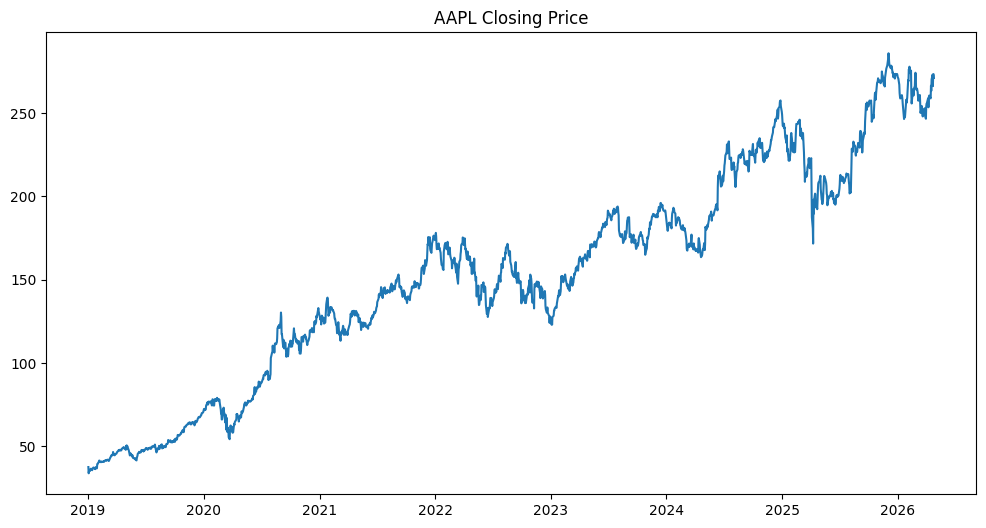

In [9]:
plt.figure(figsize=(12,6))
plt.plot(data['Close'])
plt.title("AAPL Closing Price")
plt.show()

In [10]:
close_prices= data[['Close']]
close_prices.head()

Price,Close
Date,
2019-01-02,37.503727
2019-01-03,33.768078
2019-01-04,35.209625
2019-01-07,35.131241
2019-01-08,35.800949


In [11]:
from sklearn.preprocessing import MinMaxScaler

scaler= MinMaxScaler(feature_range=(0,1))
scaled_data= scaler.fit_transform(close_prices)
scaled_data[:5]

array([[0.01481493],
       [0.        ],
       [0.00571692],
       [0.00540607],
       [0.00806201]])

In [12]:
X = []
y = []

for i in range(60, len(scaled_data)):
    X.append(scaled_data[i-60:i])
    y.append(scaled_data[i])

import numpy as np

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1778, 60, 1)
y shape: (1778, 1)


In [13]:
print(X[0])
print("Target:", y[0])

[[0.01481493]
 [0.        ]
 [0.00571692]
 [0.00540607]
 [0.00806201]
 [0.01047313]
 [0.01093461]
 [0.0095124 ]
 [0.00735569]
 [0.01024714]
 [0.01200824]
 [0.01287475]
 [0.01377892]
 [0.01046371]
 [0.01104762]
 [0.00989863]
 [0.01466425]
 [0.01328915]
 [0.01176341]
 [0.02171847]
 [0.02283928]
 [0.02291462]
 [0.02736947]
 [0.030129  ]
 [0.03018552]
 [0.0270775 ]
 [0.02726663]
 [0.0263397 ]
 [0.02772071]
 [0.02704912]
 [0.02763555]
 [0.02727612]
 [0.02775852]
 [0.02879899]
 [0.02788148]
 [0.0296881 ]
 [0.03087987]
 [0.0309745 ]
 [0.03148522]
 [0.02985834]
 [0.03157982]
 [0.03241216]
 [0.03210951]
 [0.03115414]
 [0.02924354]
 [0.02963134]
 [0.03529704]
 [0.03719826]
 [0.03795495]
 [0.03986559]
 [0.04212619]
 [0.04392339]
 [0.04251405]
 [0.04405579]
 [0.0506106 ]
 [0.04678931]
 [0.04460441]
 [0.04275993]
 [0.04434902]
 [0.04458553]]
Target: [0.04574889]


In [14]:
print(X[1])
print("Target:", y[1])

[[0.        ]
 [0.00571692]
 [0.00540607]
 [0.00806201]
 [0.01047313]
 [0.01093461]
 [0.0095124 ]
 [0.00735569]
 [0.01024714]
 [0.01200824]
 [0.01287475]
 [0.01377892]
 [0.01046371]
 [0.01104762]
 [0.00989863]
 [0.01466425]
 [0.01328915]
 [0.01176341]
 [0.02171847]
 [0.02283928]
 [0.02291462]
 [0.02736947]
 [0.030129  ]
 [0.03018552]
 [0.0270775 ]
 [0.02726663]
 [0.0263397 ]
 [0.02772071]
 [0.02704912]
 [0.02763555]
 [0.02727612]
 [0.02775852]
 [0.02879899]
 [0.02788148]
 [0.0296881 ]
 [0.03087987]
 [0.0309745 ]
 [0.03148522]
 [0.02985834]
 [0.03157982]
 [0.03241216]
 [0.03210951]
 [0.03115414]
 [0.02924354]
 [0.02963134]
 [0.03529704]
 [0.03719826]
 [0.03795495]
 [0.03986559]
 [0.04212619]
 [0.04392339]
 [0.04251405]
 [0.04405579]
 [0.0506106 ]
 [0.04678931]
 [0.04460441]
 [0.04275993]
 [0.04434902]
 [0.04458553]
 [0.04574889]]
Target: [0.04696902]


In [15]:
train_size = int(len(X) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (1422, 60, 1)
Test size: (356, 60, 1)


In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input

model= Sequential()

model.add(Input(shape=(60,1)))

model.add(LSTM(50, return_sequences=True))
model.add(Dropout(0.2))

model.add(LSTM(50))
model.add(Dropout(0.2))

model.add(Dense(1))

model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)

Epoch 1/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 11s 106ms/step - loss: 0.0192 - val_loss: 0.0071
Epoch 2/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - loss: 0.0027 - val_loss: 0.0015
Epoch 3/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - loss: 0.0024 - val_loss: 0.0016
Epoch 4/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step - loss: 0.0021 - val_loss: 0.0024
Epoch 5/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step - loss: 0.0021 - val_loss: 0.0017
Epoch 6/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 91ms/step - loss: 0.0022 - val_loss: 0.0025
Epoch 7/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 79ms/step - loss: 0.0020 - val_loss: 0.0013
Epoch 8/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 70ms/step - loss: 0.0018 - val_loss: 0.0021
Epoch 9/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step - loss: 0.0018 - val_loss: 0.0016
Epoch 10/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 5s 86ms/step - loss: 0.0016 - val_loss: 0.0016
Epoch 11/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 75ms/step - loss: 0.0017 - val_loss: 0.0023
Epoch 12/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 75ms/step - loss: 0

In [18]:
predictions= model.predict(X_test)

predictions=scaler.inverse_transform(predictions)
y_test_actual=scaler.inverse_transform(y_test)

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step


In [19]:
rmse=math.sqrt(mean_squared_error(y_test_actual, predictions))
print("RMSE:", rmse)

mape= np.mean(np.abs((y_test_actual - predictions) / y_test_actual)) * 100
print("MAPE:", mape)

RMSE: 7.567220512755977
MAPE: 2.4316532013854526


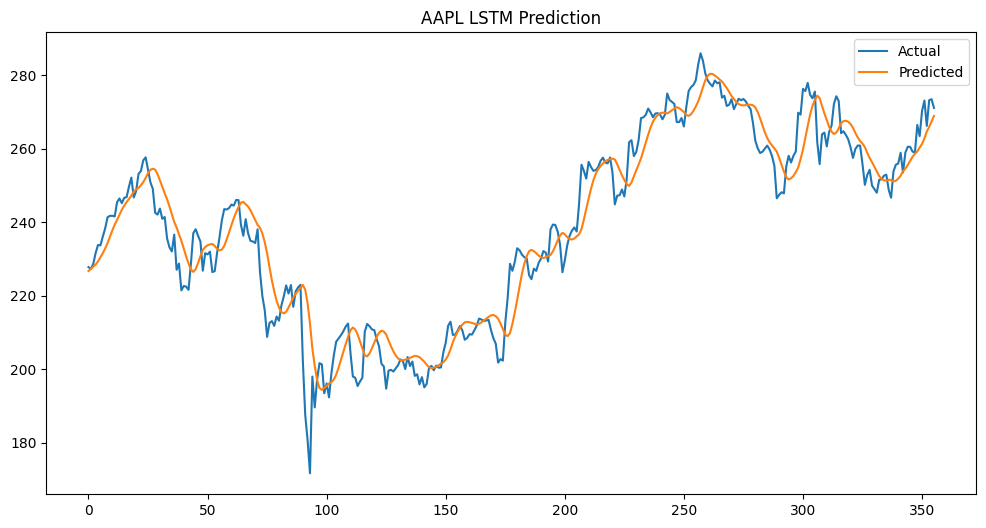

In [20]:
plt.figure(figsize=(12,6))
plt.plot(y_test_actual, label="Actual")
plt.plot(predictions, label="Predicted")
plt.legend()
plt.title("AAPL LSTM Prediction")
plt.show()

In [21]:
latest_data= yf.download('AAPL', period='90d')

[*********************100%***********************]  1 of 1 completed


In [22]:
latest_data.columns= latest_data.columns.get_level_values(0)

In [23]:
close_prices= latest_data[['Close']]
close_prices

Price,Close
Date,
2025-12-15,273.853729
2025-12-16,274.353271
2025-12-17,271.585876
2025-12-18,271.935547
2025-12-19,273.414185
...,...
2026-04-20,273.049988
2026-04-21,266.170013
2026-04-22,273.170013


In [24]:
scaled_latest= scaler.transform(close_prices)

In [25]:
last_60_days= scaled_latest[-60:]

In [26]:
future_predictions = []

current_input = last_60_days.copy()

for _ in range(7):
    
    prediction = model.predict(current_input.reshape(1,60,1))
    
    future_predictions.append(prediction[0][0])
    
    current_input = np.append(current_input[1:], prediction)
    
future_predictions = scaler.inverse_transform(
    np.array(future_predictions).reshape(-1,1)
)

print("Next 7 day predictions:")
print(future_predictions)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
Next 7 day predictions:
[[269.92422]
 [270.5339 ]
 [270.87442]
 [271.03482]
 [271.0792 ]
 [271.0512 ]
 [270.9802 ]]


In [27]:
last_date = latest_data.index[-1]

In [28]:
future_dates = pd.date_range(
    start=last_date,
    periods=8,
    freq='B'  # business days
)[1:]

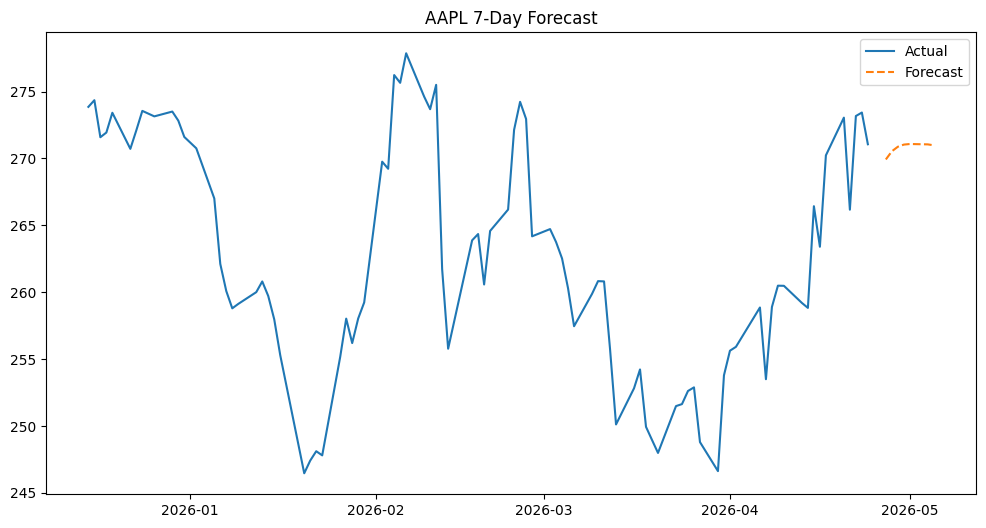

In [29]:
plt.figure(figsize=(12,6))

# Plot historical
plt.plot(latest_data.index, latest_data['Close'], label="Actual")

# Plot forecast
plt.plot(future_dates, future_predictions, label="Forecast", linestyle='--')

plt.legend()
plt.title("AAPL 7-Day Forecast")
plt.show()

In [30]:
current_price = latest_data['Close'].iloc[-1]
predicted_price = future_predictions[-1][0]

change_percentage = ((predicted_price - current_price) / current_price) * 100

if change_percentage > 2:
    signal = "BUY"
elif change_percentage < -2:
    signal = "SELL"
else:
    signal = "HOLD"

print("Current Price:", current_price)
print("Predicted (7th Day):", predicted_price)
print("Change %:", change_percentage)
print("Signal:", signal)

Current Price: 271.05999755859375
Predicted (7th Day): 270.9802
Change %: -0.029441255631836367
Signal: HOLD


In [31]:
model.save("aapl_lstm_model.keras")

In [32]:
import joblib
joblib.dump(scaler, "aapl_scaler.save")

['aapl_scaler.save']